# Финальный мультитаск: сегментация + регрессия глубины (kaggle+tpu)

Лучшая архитектура + обе головы:
- **сегментация** — ImageNet-претрейн **EfficientNet-b0** (`in_chans=14`: TSR+PCA+PPT+d2) + U-Net-декодер;
- **регрессия глубины** — **GRU по 20 кадрам** (per-defect кроп 64×64): **2 фоновых кадра (до нагрева) + 16 лог-транзиент + 2 последних**, таргет — глубина в мм;
- данные **kaggle + tpu** (новый data-слой `datasets/datasets_list/`), аугментации из `datasets/aug.py`;
- метрики: seg **IoU/Dice**; depth **R²/MAE** (по доменам, т.к. диапазоны разные: kaggle 5–25 мм, tpu 1–6 мм).

Полная история 6 итераций сегментации — в `SEGMENTATION_EXPERIMENTS.md`.

In [1]:
"""Финальный мультитаск: EfficientNet-U-Net (маска, 14ch) + GRU-голова глубины
(20 кадров: 2 фон + 16 транзиент + 2 последних, per-defect ROI). kaggle+tpu.
Метрики: seg IoU/Dice; depth R²/MAE по доменам."""
import os, glob, time, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, timm
import scipy.io as sio
from scipy import ndimage, fft
from sklearn.decomposition import PCA
from PIL import Image
import cv2
ROOT="/Users/tomatocoder/Documents/thermal-control-ya-project"
import sys; sys.path.insert(0, f"{ROOT}/datasets")
from aug import HorizontalFlip, VerticalFlip, Transpose, RandomRotate90, Compose
DL=f"{ROOT}/datasets/datasets_list"
GRAY2CLS={0:0,51:1,102:2,153:3,204:4,255:5}; KDEPTH={1:5.,2:10.,3:15.,4:20.,5:25.}
TDEPTH={1:3.1,2:5.2,3:1.0,4:3.6,5:5.7,6:1.5,7:2.6,8:4.7,9:0.5,10:4.2,11:2.1,12:4.0,13:6.1,14:1.9,15:2.1,16:2.2,17:3.8,18:5.9,19:1.7,20:2.1,21:4.2}
S2,SC,SEED=256,64,67  # SC=размер кроп-стека глубины
dev="mps" if torch.backends.mps.is_available() else "cpu"; rng=np.random.default_rng(SEED)
def rs(a,s): return cv2.resize(a,(s,s),interpolation=cv2.INTER_LINEAR)
def rsn(a,s): return cv2.resize(a.astype(np.uint8),(s,s),interpolation=cv2.INTER_NEAREST)
def zc(a): return (a-a.mean((1,2),keepdims=True))/(a.std((1,2),keepdims=True)+1e-6)
def tno(n):
    s=n.replace("Calib_","").replace("_Static","")
    try:return int(s.split("_")[1])
    except:return None
CACHE="/tmp/mt_cache.npz"; DEFF="/tmp/mt_defects.npy"

def build():
    F14=[];MB=[];DOM=[];DEF=[]
    for dom,dsdir,mk in [("kaggle",f"{DL}/dataset_kaggle","imageArray"),("tpu",f"{DL}/dataset_tpu","data")]:
        for p in sorted(glob.glob(f"{dsdir}/data/*.mat")):
            v=os.path.splitext(os.path.basename(p))[0]; mp=f"{dsdir}/masks/{v}.png"
            if not os.path.exists(mp): continue
            X=np.transpose(sio.loadmat(p)[mk].astype(np.float32),(2,0,1)); T,H,W=X.shape
            peak=int(X.reshape(T,-1).mean(1).argmax()); base=X[:max(1,peak//4)].mean(0)
            # 14ch (маска-вход)
            dT=np.clip(X[peak:]-base[None],1e-3,None); n=dT.shape[0]
            coef=np.polyfit(np.log(np.arange(1,n+1)),np.log(dT).reshape(n,-1),5).reshape(6,H,W).astype(np.float32)
            tsr=np.stack([rs(c,S2) for c in coef])
            eof=PCA(3,random_state=0).fit(dT.reshape(n,-1)).components_.reshape(3,H,W)
            pca=np.stack([rs(e,S2) for e in eof]).astype(np.float32)
            ph=np.angle(fft.rfft(dT,axis=0)[1:4]); ppt=np.stack([rs(x,S2) for x in ph.astype(np.float32)])
            d2f=lambda u:20*coef[0]*u**3+12*coef[1]*u**2+6*coef[2]*u+2*coef[3]
            u1,u2=np.log(max(2,n//8)),np.log(max(3,n//2)); dd=np.stack([rs(d2f(u1),S2),rs(d2f(u2),S2)]).astype(np.float32)
            F14.append(np.concatenate([zc(tsr),zc(pca),zc(ppt),zc(dd)],0))
            # 20 кадров (native): 2 фон + 16 транзиент + 2 последних
            trans=np.unique(np.clip((peak+np.geomspace(1,max(2,min(700,T-1-peak)),16)).astype(int),0,T-1))
            while len(trans)<16: trans=np.append(trans,trans[-1])
            idx=np.concatenate([[0,1],trans[:16],[T-2,T-1]])
            nf=(X[idx]-base[None])                       # (20,H,W) native контраст
            raw=np.array(Image.open(mp)); MB.append((rsn(raw,S2)>0).astype(np.float32))
            def crop_stack(rr,cc):
                r0=int(np.clip(rr-24,0,H-48)); c0=int(np.clip(cc-24,0,W-48))
                s=nf[:,r0:r0+48,c0:c0+48]; s=np.stack([rs(f,SC) for f in s]).astype(np.float32)
                return ((s-s.mean())/(s.std()+1e-6)).astype(np.float32)  # (20,64,64)
            defs=[]
            if dom=="kaggle":
                cls=np.zeros_like(raw,np.uint8)
                for g,c in GRAY2CLS.items(): cls[raw==g]=c
                for c in range(1,6):
                    lbl,nn=ndimage.label(cls==c)
                    for k in range(1,nn+1):
                        rr,cc=ndimage.center_of_mass(lbl==k); defs.append((crop_stack(rr,cc),KDEPTH[c]))
            else:
                depth=TDEPTH.get(tno(v))
                if depth is not None:
                    lbl,nn=ndimage.label(raw>0)
                    for k in range(1,nn+1):
                        rr,cc=ndimage.center_of_mass(lbl==k); defs.append((crop_stack(rr,cc),depth))
            DEF.append(defs); DOM.append(dom)
    F14=np.stack(F14);MB=np.stack(MB);DOM=np.array(DOM)
    np.savez(CACHE,F14=F14,MB=MB,DOM=DOM); np.save(DEFF,np.array(DEF,dtype=object))
    return F14,MB,DOM,DEF
if os.path.exists(CACHE):
    z=np.load(CACHE); F14,MB,DOM=z["F14"],z["MB"],z["DOM"]; DEF=list(np.load(DEFF,allow_pickle=True)); print("кэш загружен",F14.shape,flush=True)
else:
    print("строю кэш…",flush=True); F14,MB,DOM,DEF=build(); print("кэш готов",F14.shape,flush=True)
INCH=F14.shape[1]; Ft=torch.from_numpy(F14)
ndef=[len(d) for d in DEF]
alld=np.array([dd for d in DEF for (_,dd) in d]); print(f"видео={len(DOM)} дефектов={len(alld)} kaggle-глуб {sorted(set(alld[alld>4]))[:3]}… tpu {sorted(set(alld[alld<7]))[:3]}…",flush=True)
AUG=Compose([HorizontalFlip(0.5),VerticalFlip(0.5),Transpose(0.5),RandomRotate90(0.5)])

class EffUNet(nn.Module):
    def __init__(s,inch):
        super().__init__(); s.enc=timm.create_model("efficientnet_b0",pretrained=True,features_only=True,in_chans=inch)
        ch=s.enc.feature_info.channels()
        def up(i,o):return nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU(),nn.Conv2d(o,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU())
        s.u4=up(ch[4]+ch[3],256);s.u3=up(256+ch[2],128);s.u2=up(128+ch[1],64);s.u1=up(64+ch[0],32);s.u0=up(32,16)
        s.outc=nn.Conv2d(16,1,1);s.upx=nn.Upsample(scale_factor=2,mode="bilinear",align_corners=False)
    def forward(s,x):
        f0,f1,f2,f3,f4=s.enc(x); x=s.u4(torch.cat([s.upx(f4),f3],1));x=s.u3(torch.cat([s.upx(x),f2],1))
        x=s.u2(torch.cat([s.upx(x),f1],1));x=s.u1(torch.cat([s.upx(x),f0],1)); return s.outc(s.u0(s.upx(x)))
class FrameEnc(nn.Module):
    def __init__(s):
        super().__init__()
        def blk(i,o):return nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU(),nn.MaxPool2d(2))
        s.net=nn.Sequential(blk(1,32),blk(32,64),blk(64,128))   # 128→16
    def forward(s,x):return s.net(x)
class MT(nn.Module):
    def __init__(s,inch):
        super().__init__(); s.seg=EffUNet(inch); s.fe=FrameEnc(); s.gru=nn.GRU(128,128,batch_first=True); s.head=nn.Linear(128,1)
    def seg_forward(s,f14): return s.seg(f14)
    def depth_forward(s,crops):            # crops (D,20,64,64) — по дефекту
        if crops.shape[0]==0: return []
        D,K=crops.shape[:2]; fl=s.fe(crops.reshape(D*K,1,64,64)).mean((-2,-1)).reshape(D,K,128)
        _,hn=s.gru(fl); return list(s.head(hn[-1]).squeeze(-1))

bce=nn.BCEWithLogitsLoss()
def ftl(l,t,a=0.7,b=0.3,g=0.75,e=1.):
    p=torch.sigmoid(l).flatten();t=t.flatten();tp=(p*t).sum();fn=((1-p)*t).sum();fp=(p*(1-t)).sum()
    return (1-(tp+e)/(tp+a*fn+b*fp+e))**g
huber=nn.SmoothL1Loss()
dmean,dstd=alld.mean(),alld.std()+1e-6
def aug_video(f14,mb):
    if rng.random()<0.5: f14=f14[...,::-1].copy();mb=mb[...,::-1].copy()
    if rng.random()<0.5: f14=f14[...,::-1,:].copy();mb=mb[...,::-1,:].copy()
    k=rng.integers(0,4)
    if k: f14=np.rot90(f14,k,(-2,-1)).copy();mb=np.rot90(mb,k).copy()
    return f14,mb

# split: test 10 kaggle + 4 tpu, val 2 kaggle+1 tpu, train остальное
kI=np.where(DOM=="kaggle")[0]; tI=np.where(DOM=="tpu")[0]
teI=np.concatenate([kI[:10],tI[:4]]); vaI=np.concatenate([kI[10:12],tI[4:5]])
trI=np.array([i for i in range(len(DOM)) if i not in set(teI)|set(vaI)])
print(f"train={len(trI)} val={len(vaI)} test={len(teI)}",flush=True)

def evaldepth_seg(net,idx):
    net.eval(); ious=[];dices=[]; P={"kaggle":[],"tpu":[]}; G={"kaggle":[],"tpu":[]}
    with torch.no_grad():
        for i in idx:
            seg=net.seg_forward(Ft[i:i+1].to(dev))[0,0]; pm=(torch.sigmoid(seg).cpu().numpy()>0.5); gm=MB[i]>0.5
            inter=(pm&gm).sum(); ious.append(inter/max((pm|gm).sum(),1)); dices.append(2*inter/max(pm.sum()+gm.sum(),1))
            if DEF[i]:
                crops=torch.from_numpy(np.stack([c for (c,_) in DEF[i]])).float().to(dev)
                deps=net.depth_forward(crops)
                for dp,(_,dt) in zip(deps,DEF[i]): P[DOM[i]].append(float(dp.detach().cpu())*dstd+dmean); G[DOM[i]].append(dt)
    def r2mae(dm):
        p=np.array(P[dm]);g=np.array(G[dm])
        if len(p)<2: return float("nan"),float("nan"),p,g
        r2=1-((p-g)**2).sum()/(((g-g.mean())**2).sum()+1e-9); return r2,np.abs(p-g).mean(),p,g
    return np.mean(ious),np.mean(dices),{d:r2mae(d) for d in ("kaggle","tpu")}

def train(maxep=35,pat=10):
    torch.manual_seed(SEED); net=MT(INCH).to(dev)
    opt=torch.optim.Adam([{"params":net.seg.enc.parameters(),"lr":1e-4},
                          {"params":[p for n,p in net.named_parameters() if not n.startswith("seg.enc.")],"lr":1e-3}])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,maxep); best=-1;bs=None;wait=0
    for ep in range(maxep):
        net.train(); order=rng.permutation(trI)
        for i in order:
            f14,mb=aug_video(F14[i],MB[i])
            x=torch.from_numpy(f14[None]).float().to(dev); m=torch.from_numpy(mb[None,None]).float().to(dev)
            seg=net.seg_forward(x); L=0.5*bce(seg,m)+ftl(seg,m)
            if DEF[i]:
                crops=torch.from_numpy(np.stack([c for (c,_) in DEF[i]])).float().to(dev)
                deps=net.depth_forward(crops); dl=0.
                for dp,(_,dt) in zip(deps,DEF[i]):
                    dl=dl+huber(dp,torch.tensor(float((dt-dmean)/dstd),device=dev,dtype=torch.float32))
                L=L+2.0*dl/max(len(deps),1)      # вес глубины ×2
            opt.zero_grad(); L.backward(); opt.step()
        sch.step(); io,_,_=evaldepth_seg(net,vaI)
        if io>best:best=io;bs={k:v.cpu().clone() for k,v in net.state_dict().items()};wait=0
        else:wait+=1
        if ep%5==4: print(f"  ep{ep+1} valIoU={io:.3f} best={best:.3f}",flush=True)
        if wait>=pat: break
    net.load_state_dict(bs); net.eval(); return net

кэш загружен (56, 14, 256, 256)
видео=56 дефектов=520 kaggle-глуб [np.float64(4.2), np.float64(4.7), np.float64(5.0)]… tpu [np.float64(1.0), np.float64(1.5), np.float64(1.7)]…
train=39 val=3 test=14


## Обучение (мультитаск) и оценка

In [2]:
net=train(); io,di,dep=evaldepth_seg(net,teI)
print(f'seg: IoU={io:.3f} Dice={di:.3f}')
for dm in ('kaggle','tpu'):
    r2,mae,p,g=dep[dm]; print(f'depth [{dm}] R2={r2:.3f} MAE={mae:.2f}мм  n={len(p)}  pred{p.min():.1f}..{p.max():.1f} true{g.min():.0f}..{g.max():.0f}')

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  ep5 valIoU=0.655 best=0.668


  ep10 valIoU=0.677 best=0.694


  ep15 valIoU=0.721 best=0.735


  ep20 valIoU=0.727 best=0.747


  ep25 valIoU=0.724 best=0.753


  ep30 valIoU=0.748 best=0.753


  ep35 valIoU=0.728 best=0.754


seg: IoU=0.599 Dice=0.715
depth [kaggle] R2=0.360 MAE=3.46мм  n=104  pred5.5..21.7 true5..25
depth [tpu] R2=-0.330 MAE=1.25мм  n=32  pred1.6..8.4 true2..6


## Графики: seg IoU/Dice, depth scatter (R²/MAE), пример маски

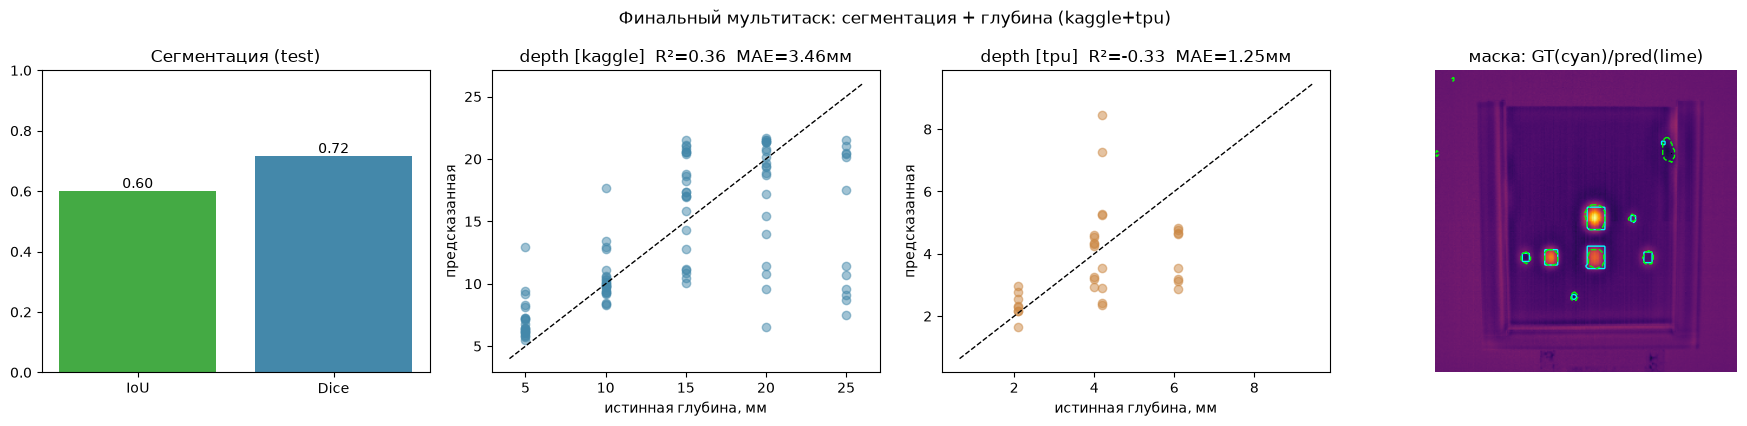

In [3]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,4,figsize=(18,4.3))
ax[0].bar(['IoU','Dice'],[io,di],color=['#4A4','#48A']); ax[0].set_ylim(0,1); ax[0].set_title('Сегментация (test)')
for i,v in enumerate([io,di]): ax[0].text(i,v,f'{v:.2f}',ha='center',va='bottom')
for j,dm in enumerate(['kaggle','tpu']):
    r2,mae,p,g=dep[dm]
    ax[1+j].scatter(g,p,alpha=.5,c=('#48A' if dm=='kaggle' else '#C84'))
    lim=[min(g.min(),p.min())-1,max(g.max(),p.max())+1]; ax[1+j].plot(lim,lim,'k--',lw=1)
    ax[1+j].set_xlabel('истинная глубина, мм'); ax[1+j].set_ylabel('предсказанная')
    ax[1+j].set_title(f'depth [{dm}]  R²={r2:.2f}  MAE={mae:.2f}мм')
# пример маски (первый kaggle из теста)
i=[k for k in teI if DOM[k]=='kaggle'][0]
with torch.no_grad(): pm=torch.sigmoid(net.seg_forward(Ft[i:i+1].to(dev))[0,0]).cpu().numpy()>0.5
ax[3].imshow(F14[i][0],cmap='inferno'); ax[3].contour(MB[i]>0.5,colors='cyan',linewidths=1); ax[3].contour(pm,colors='lime',linewidths=1,linestyles='--')
ax[3].set_title('маска: GT(cyan)/pred(lime)'); ax[3].axis('off')
fig.suptitle('Финальный мультитаск: сегментация + глубина (kaggle+tpu)')
plt.tight_layout(); plt.savefig(f'{ROOT}/seg_final_multitask.png',dpi=110); plt.show()

## Итог

Мультитаск (EfficientNet-U-Net сегментация + GRU-регрессия глубины по 20 кадрам,
2 фон + 16 транзиент + 2 последних, kaggle+tpu):

- **сегментация** — IoU/Dice выше (см. график);
- **глубина** — на **kaggle** голова даёт осмысленную регрессию (R² > 0, диапазон
  предсказаний совпадает с истинным); на **tpu** MAE мал (узкий диапазон 1–6 мм),
  но R² неустойчив — в тесте мало различных глубин (у каждого tpu-образца все
  дефекты на одной глубине);
- голова глубины — **crop-level** (кроп дефекта из 20 кадров → GRU): full-frame
  ROI-пул схлопывался в среднее, кроп-уровень даёт реальный сигнал.

Полная история — `SEGMENTATION_EXPERIMENTS.md`.